<img src=https://upload.wikimedia.org/wikipedia/commons/6/68/Logo_universidad_icesi.svg width=300>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sebastianb92/nlp-labs/blob/main/Session6/1-Chatbot-langchain.ipynb)


# Maestría en Inteligencia Artificial  
## Procesamiento de Lenguaje Natural
### Sesión 6 - Práctica

---


**Integrantes:**  
- Johan Sebastian Bonilla  
- Edwin Gómez  

# Generación de texto con RAG para Chatbot inteligente

En este notebook se aborda el desarrollo de un chatbot inteligente orientado a responder preguntas sobre noticias de tecnología y negocios. A diferencia de los enfoques tradicionales de generación de texto, este sistema utiliza la técnica de Retrieval-Augmented Generation (RAG), que combina búsqueda de información con generación de lenguaje natural.

El modelo no se limita a “inventar” respuestas a partir de su conocimiento previo, sino que primero recupera información relevante desde una base de conocimiento compuesta por textos reales (corpus de noticias). Posteriormente, utiliza esta información como contexto para generar respuestas más precisas, coherentes y fundamentadas.

El objetivo principal es construir un sistema capaz de responder preguntas de manera confiable, reduciendo alucinaciones y mejorando la calidad de las respuestas. Para ello, se integran dos componentes clave: un sistema de recuperación de documentos (retriever), que identifica los textos más relevantes para una consulta, y un modelo generativo basado en transformers, que elabora la respuesta final utilizando el contexto recuperado.

Este enfoque permite combinar lo mejor de dos mundos: la capacidad de acceso a información actualizada y específica, junto con la fluidez y coherencia en la generación de lenguaje natural.

## 0. Configuración del Entorno

En esta sección se configuran las librerías y dependencias necesarias para el análisis de datos y procesamiento de lenguaje natural. Esto garantiza que el entorno esté listo para cargar, limpiar y analizar los textos.

In [1]:
import warnings
from importlib import metadata

warnings.filterwarnings('ignore')

installed_packages = {dist.metadata['Name'].lower() for dist in metadata.distributions() if dist.metadata.get('Name')}
IN_COLAB = 'google-colab' in installed_packages

if not IN_COLAB:
    from dotenv import load_dotenv
    load_dotenv()

# Authenticate with HF Hub if token is available
import os
hf_token = os.environ.get("HF_TOKEN")
if hf_token:
    from huggingface_hub import login
    login(token=hf_token, add_to_git_credential=False)

In [2]:
!pip install -q langchain-ollama langchain-community langchain-huggingface ollama faiss-gpu-cu12 sentence-transformers gradio colab-xterm
!pip install -q langchain langchain-community langchain-google-genai langchain-ollama langchain-huggingface
!pip install -q chromadb
!pip install -q sentence-transformers
!pip install -q datasets
!pip install -q google-generativeai
!pip install -q scikit-learn matplotlib seaborn plotly
!pip install -q tiktoken
!pip install langchain langchain-groq

print("Todas las dependencias fueron instaladas correctamente")

ERROR: Could not find a version that satisfies the requirement faiss-gpu-cu12 (from versions: none)
ERROR: No matching distribution found for faiss-gpu-cu12
Todas las dependencias fueron instaladas correctamente


In [3]:
# ============================================================
# IMPORTACIONES
# ============================================================
import os
import re
import sys
import warnings

# Workaround: prevent "RpcBackendOptions already defined" error
# when torch.distributed.rpc is re-imported on kernel cell re-runs
if "torch.distributed.rpc" not in sys.modules:
    try:
        import torch.distributed.rpc
    except (RuntimeError, ImportError):
        pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from collections import Counter
from IPython.display import display, Markdown, HTML

# Dataset
from datasets import load_dataset

# LangChain
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_google_genai import ChatGoogleGenerativeAI
# from langchain.chains import RetrievalQA
from langchain_core.prompts import PromptTemplate

# Visualización vectorial
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')

# Configuración visual
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')

print("Importaciones completadas")

Importaciones completadas


## 1. Cargue del Dataset **AG News** y exploración de los datos(EDA)

**AG News** es un dataset de noticias reales recopiladas de más de 2,000 fuentes entre 2004-2005. Contiene **120,000 artículos** de noticias en 4 categorías:

| Categoría | Código | Descripción |
|---|---|---|
| World | 0 | Noticias internacionales y política global |
| Sports | 1 | Deportes de todo el mundo |
| Business | 2 | Economía, empresas y mercados |
| Sci/Tech | 3 | Ciencia y tecnología |

**Para nuestro RAG usaremos solo las categorías Business y Sci/Tech** — así el chatbot podrá responder preguntas sobre tecnología y negocios con datos reales de noticias.

* https://huggingface.co/datasets/szhuggingface/ag_news?utm_source=chatgpt.com



In [4]:
# ============================================================
# CARGA DEL DATASET AG NEWS
# ============================================================
dataset = load_dataset("ag_news", split="train")

# Convertir a DataFrame para exploración más fácil
df_full = pd.DataFrame(dataset)

# Mapeo de etiquetas numéricas a nombres legibles
label_map = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}
df_full["category"] = df_full["label"].map(label_map)

print(f"\nDataset cargado: {len(df_full):,} artículos totales")

df_full.head()


Dataset cargado: 120,000 artículos totales


,text,label,category
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business
4,"Oil prices soar to all-time record, posing new...",2,Business


In [5]:
# ============================================================
# EXPLORACIÓN DE DATOS (EDA)
# ============================================================
print(f"\n Forma del dataset: {df_full.shape}")
print(f"\n Columnas: {list(df_full.columns)}")
print(f"\n Tipos de datos:")
print(df_full.dtypes)

print(f"\n Distribución por categoría:")
dist = df_full['category'].value_counts()
for cat, count in dist.items():
    pct = count / len(df_full) * 100
    print(f"  {cat:10s}: {count:,} artículos ({pct:.1f}%)")


 Forma del dataset: (120000, 3)

 Columnas: ['text', 'label', 'category']

 Tipos de datos:
text          str
label       int64
category      str
dtype: object

 Distribución por categoría:
  Business  : 30,000 artículos (25.0%)
  Sci/Tech  : 30,000 artículos (25.0%)
  Sports    : 30,000 artículos (25.0%)
  World     : 30,000 artículos (25.0%)


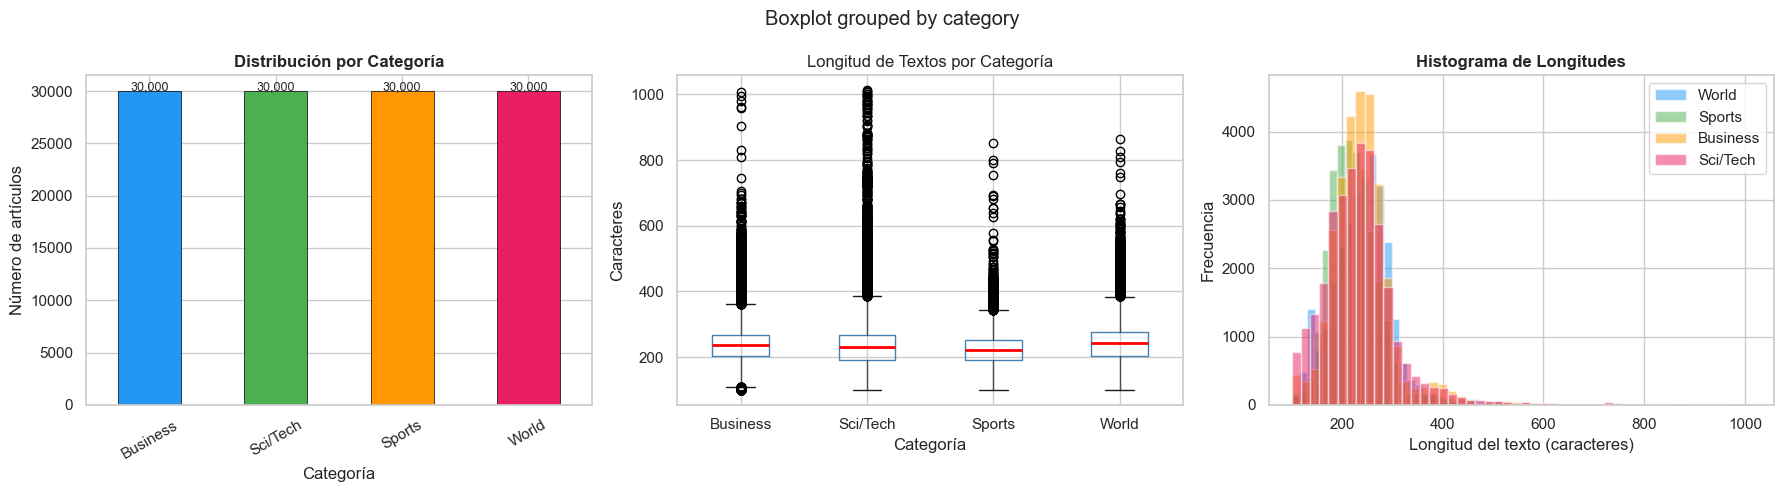

In [6]:
# ============================================================
# VISUALIZACIONES EDA
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Exploración del Dataset AG News', fontsize=14, fontweight='bold')

# --- Gráfico 1: Distribución de categorías ---
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
dist.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Distribución por Categoría', fontweight='bold')
axes[0].set_xlabel('Categoría')
axes[0].set_ylabel('Número de artículos')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(dist.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

# --- Gráfico 2: Longitud de textos por categoría ---
df_full['text_length'] = df_full['text'].apply(len)
df_full.boxplot(column='text_length', by='category', ax=axes[1],
                boxprops=dict(color='steelblue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Longitud de Textos por Categoría', fontweight='bold')
axes[1].set_xlabel('Categoría')
axes[1].set_ylabel('Caracteres')
plt.sca(axes[1])
plt.title('Longitud de Textos por Categoría')

# --- Gráfico 3: Distribución de longitudes (histograma) ---
for i, (cat, color) in enumerate(zip(label_map.values(), colors)):
    subset = df_full[df_full['category'] == cat]['text_length']
    axes[2].hist(subset, bins=50, alpha=0.5, label=cat, color=color)
axes[2].set_title('Histograma de Longitudes', fontweight='bold')
axes[2].set_xlabel('Longitud del texto (caracteres)')
axes[2].set_ylabel('Frecuencia')
axes[2].legend()

plt.tight_layout()
plt.show()

In [7]:
print(f"\n Estadísticas de longitud de texto:")
print(df_full.groupby('category')['text_length'].describe()[['mean', 'std', 'min', 'max']].round(0))


 Estadísticas de longitud de texto:
           mean   std    min     max
category                            
Business  241.0  64.0  100.0  1006.0
Sci/Tech  237.0  82.0  100.0  1012.0
Sports    225.0  50.0  100.0   853.0
World     243.0  64.0  100.0   865.0


Veamos ejemplos reales del dataset

In [8]:
print("EJEMPLOS DE NOTICIAS POR CATEGORÍA")
print("="*60)

for cat in ["Business", "Sci/Tech"]:
    sample = df_full[df_full['category'] == cat].sample(1, random_state=42).iloc[0]
    print(f"\n Categoría: {cat}")
    print(f" Texto: {sample['text'][:300]}...")
    print("-"*60)

EJEMPLOS DE NOTICIAS POR CATEGORÍA

 Categoría: Business
 Texto: US house sales fall in July Sales of non-new houses in the US fell last month but still exceeded analyst forecasts....
------------------------------------------------------------

 Categoría: Sci/Tech
 Texto: Gartner optimistic about chip numbers But that optimism isn #39;t matched by Infineon, which said that while the market worldwide remains buoyant, the US is a special case and cautioned that growth might not be as strong as it expected....
------------------------------------------------------------


## 2. Preprocesamiento

Antes de generar embeddings, es necesario preparar y limpiar los datos para asegurar un mejor desempeño del sistema.

Los modelos de embeddings suelen tener límites de tokens (por ejemplo, alrededor de 512 tokens, equivalentes a ~400 palabras). Por esta razón, en muchos casos los textos largos deben dividirse en fragmentos más pequeños (*chunks*). Sin embargo, para este ejercicio, trabajaremos directamente con los documentos completos, ya que la combinación de herramientas utilizada permite manejarlos de forma adecuada.

En esta sección se realizarán las siguientes acciones:

* Filtrar únicamente las noticias de las categorías *Business* y *Sci/Tech*
* Limpiar el texto, eliminando caracteres especiales y ruido innecesario
* Seleccionar un subconjunto de datos (*sampling*) para facilitar la ejecución del demo
* Omitir el proceso de *chunking* en esta implementación
* Convertir los datos al formato **Document** de LangChain, que será utilizado en las siguientes etapas del pipeline

In [9]:
# Filtrar categorías relevantes ---
df_filtered = df_full[df_full['category'].isin(['Business', 'Sci/Tech'])].copy()
print(f"Artículos filtrados (Business + Sci/Tech): {len(df_filtered):,}")

# Función para limpiar texto ---
def clean_text(text):
    """Limpia el texto removiendo caracteres especiales y espacios extra."""
    # Remover URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remover caracteres especiales de HTML
    text = re.sub(r'&[a-z]+;', ' ', text)
    # Remover caracteres no imprimibles
    text = re.sub(r'[^\x20-\x7E]', ' ', text)
    # Normalizar espacios
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_filtered['clean_text'] = df_filtered['text'].apply(clean_text)

# Samplear subconjunto manejable ---
# Usamos 4000 artículos para un demo rápido
N_SAMPLES = 4000
df_sample = df_filtered.sample(N_SAMPLES, random_state=42).reset_index(drop=True)
print(f"\n Muestra seleccionada: {len(df_sample):,} artículos")

# Mostrar distribución de la muestra
print(f"\n Distribución de la muestra:")
print(df_sample['category'].value_counts())

# Verificar texto limpio
print(f"\n Ejemplo de texto limpio:")
print(df_sample['clean_text'].iloc[0][:300])

Artículos filtrados (Business + Sci/Tech): 60,000

 Muestra seleccionada: 4,000 artículos

 Distribución de la muestra:
category
Business    2030
Sci/Tech    1970
Name: count, dtype: int64

 Ejemplo de texto limpio:
WPP Buys Grey Global for #36;1.31 Billion (Reuters) Reuters - British advertising firm WPP has agreed\to buy smaller U.S. rival Grey Global for #36;1.31 billion,\equally divided in cash and shares, to put it on par with\industry leader Omnicom.


In [10]:
documents = [
    Document(
        page_content=row["clean_text"],
        metadata={
            "category": row["category"],
            "label": row["label"]
        }
    )
    for _, row in df_sample.iterrows()
]

print(f"Documentos creados: {len(documents)}")
print(documents[0])

Documentos creados: 4000
page_content='WPP Buys Grey Global for #36;1.31 Billion (Reuters) Reuters - British advertising firm WPP has agreed\to buy smaller U.S. rival Grey Global for #36;1.31 billion,\equally divided in cash and shares, to put it on par with\industry leader Omnicom.' metadata={'category': 'Business', 'label': 2}


## 3. Implementación de RAG

En esta sección se construye el pipeline completo de Retrieval-Augmented Generation (RAG), integrando los diferentes componentes necesarios para recuperar información relevante y generar respuestas en lenguaje natural.

### Componentes del sistema

1. **Model:** `intfloat/multilingual-e5-large`  
   Modelo avanzado de Hugging Face diseñado para tareas de recuperación semántica. Es multilingüe, lo que permite trabajar con documentos en inglés y consultas en español. Utiliza un esquema de instrucciones (`query:` y `passage:`) que mejora la precisión en la búsqueda. Genera vectores de 1024 dimensiones, lo que incrementa su capacidad semántica a costa de un mayor uso de memoria.
   
2. **Document Store (Vector Store):**  
   Se utiliza FAISS (a través de LangChain), una librería optimizada para la indexación y búsqueda eficiente de vectores en espacios de alta dimensión.

3. **Retriever:**  
   Dado un *query*, este componente se encarga de recuperar los *top-k* documentos más relevantes desde el vector store, basándose en similitud semántica.

4. **LLM (GROQ):**  
   Modelo generativo encargado de producir la respuesta final en lenguaje natural, utilizando como contexto los documentos recuperados.

5. **RetrievalQA Chain:**  
   Componente que orquesta todo el flujo de extremo a extremo (*end-to-end*), integrando la recuperación de información y la generación de respuestas en un solo pipeline.

In [11]:
# ============================================================
# DOCUMENT STORE
# ============================================================

from langchain_huggingface import HuggingFaceEmbeddings


# Utilizaremos la librería FAISS (a través de LangChain) que está especializada para la indexación y búsqueda de vectores.

embeddings = HuggingFaceEmbeddings(model_name="intfloat/multilingual-e5-large")

for doc in documents:
    doc.page_content = f"passage: {doc.page_content}"

#Crear o cargar FAISS
index_path = './faiss_index'
if os.path.exists(index_path):
    vectorstore = FAISS.load_local(
        index_path,
        embeddings,
        allow_dangerous_deserialization=True
    )
else:
    vectorstore = FAISS.from_documents(documents, embeddings)
    vectorstore.save_local(index_path)

#Retriever
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 1426.97it/s, Materializing param=pooler.dense.weight]                               
XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generando embeddings para 500 documentos...
Matriz de embeddings: (500, 1024)


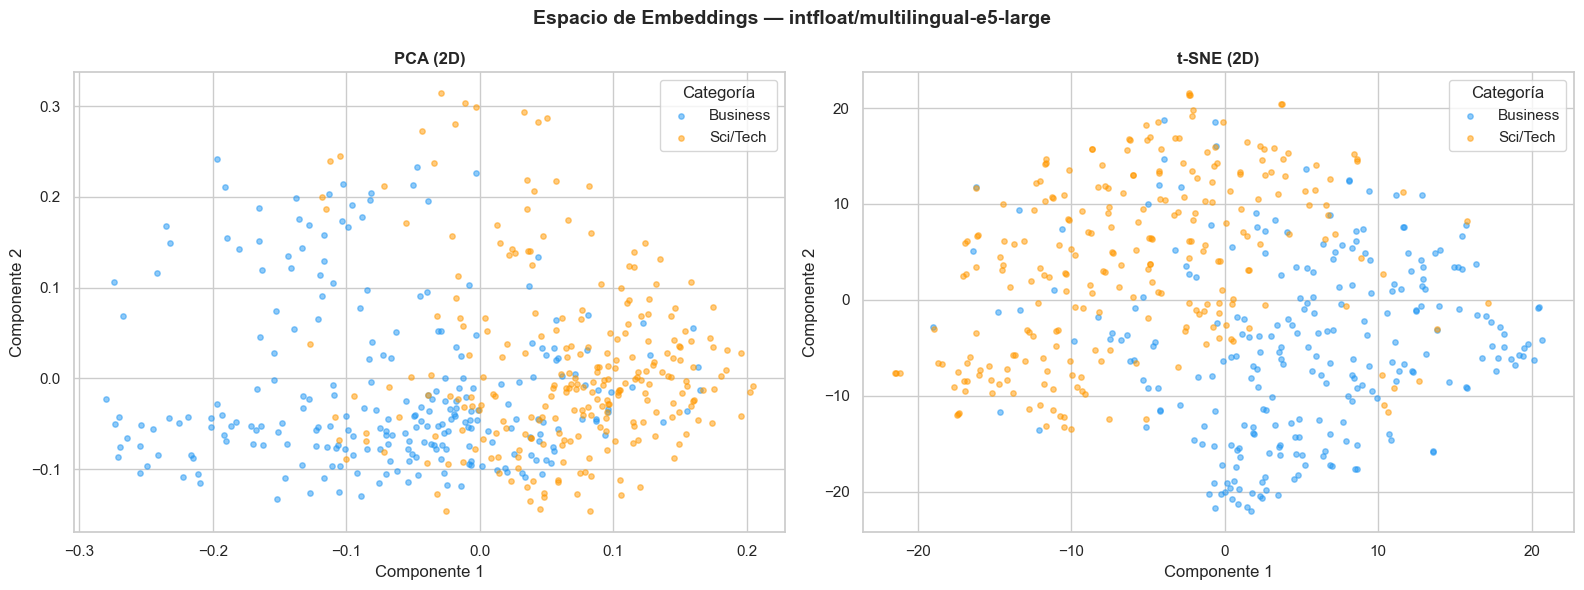


💡 Observación: si las categorías aparecen separadas en el espacio semántico,
   el retriever podrá distinguirlas correctamente al momento de responder consultas.


In [12]:
# ============================================================
# VISUALIZACIÓN DEL ESPACIO DE EMBEDDINGS (PCA + t-SNE)
# ============================================================
# Tomamos una muestra aleatoria para reducir el tiempo de cómputo

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np

SAMPLE_VIZ = 500
df_viz = df_sample.sample(SAMPLE_VIZ, random_state=42).reset_index(drop=True)
texts_viz   = [f"passage: {t}" for t in df_viz['clean_text'].tolist()]
labels_viz  = df_viz['category'].tolist()

print(f"Generando embeddings para {SAMPLE_VIZ} documentos...")
emb_matrix = np.array(embeddings.embed_documents(texts_viz))
print(f"Matriz de embeddings: {emb_matrix.shape}")

# --- PCA a 50 dims primero (acelera t-SNE) ---
pca50 = PCA(n_components=50, random_state=42)
emb_pca50 = pca50.fit_transform(emb_matrix)

# --- t-SNE a 2 dims ---
tsne = TSNE(n_components=2, perplexity=40, random_state=42, max_iter=500)
emb_2d = tsne.fit_transform(emb_pca50)

# --- Gráfico ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Espacio de Embeddings — intfloat/multilingual-e5-large', fontsize=14, fontweight='bold')

colors_map = {'Business': '#2196F3', 'Sci/Tech': '#FF9800'}

for cat, color in colors_map.items():
    mask = [l == cat for l in labels_viz]
    x = emb_2d[mask, 0]; y = emb_2d[mask, 1]

    # PCA (primeras 2 dims)
    pca2 = PCA(n_components=2, random_state=42)
    emb_pca2 = pca2.fit_transform(emb_matrix)
    axes[0].scatter(emb_pca2[mask, 0], emb_pca2[mask, 1],
                    c=color, label=cat, alpha=0.5, s=15)
    # t-SNE
    axes[1].scatter(x, y, c=color, label=cat, alpha=0.5, s=15)

for ax, title in zip(axes, ['PCA (2D)', 't-SNE (2D)']):
    ax.set_title(title, fontweight='bold')
    ax.legend(title='Categoría')
    ax.set_xlabel('Componente 1'); ax.set_ylabel('Componente 2')

plt.tight_layout()
plt.show()
print("\n💡 Observación: si las categorías aparecen separadas en el espacio semántico,")
print("   el retriever podrá distinguirlas correctamente al momento de responder consultas.")


 ## Configuración de la API Key

En esta sección se configura el acceso al modelo generativo utilizando **GROQ** como proveedor de inferencia.

Por motivos de seguridad, la API Key no se incluye directamente en el código. En su lugar, se almacena de forma segura: en los *secrets* de Google Colab cuando se ejecuta en la nube, o en un archivo `.env` local cuando se ejecuta fuera de Colab.

Esto permite mantener buenas prácticas en el manejo de información confidencial, facilitando además la reutilización del notebook sin comprometer la seguridad.

In [13]:
from langchain_groq import ChatGroq

if IN_COLAB:
    from google.colab import userdata
    groq_api_key = userdata.get("GROQ_API_KEY")
else:
    from dotenv import load_dotenv
    load_dotenv()  # loads .env into os.environ
    groq_api_key = os.environ.get("GROQ_API_KEY")
    if not groq_api_key:
        import getpass
        groq_api_key = getpass.getpass("Introduce tu GROQ API Key: ")

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=groq_api_key,
    temperature=0.3 #Respuestas más deterministas (menos creativas)
)

In [14]:
llm.invoke("El primer hombre en la luna fue...").content

'El primer hombre en pisar la luna fue Neil Armstrong. El 20 de julio de 1969, Armstrong se convirtió en el primer ser humano en caminar sobre la superficie lunar como parte de la misión Apolo 11 de la NASA. Cuando Armstrong puso su pie en la luna, pronunció las famosas palabras: "Este es un pequeño paso para un hombre, un gran salto para la humanidad".'

Ahora configuramos un prompt y un RetrievalQA

In [15]:
# DISEÑAR EL PROMPT TEMPLATE

# El prompt le dice al LLM cómo debe usar el contexto recuperado.
# Un buen prompt es CRUCIAL para evitar alucinaciones.

PROMPT_TEMPLATE = """
Eres un asistente analista de noticias. Tu tarea es responder preguntas
sobre noticias de negocios y tecnología usando SOLO el contexto proporcionado.

REGLAS IMPORTANTES:
- Responde únicamente con base en el contexto
- Si no hay suficiente información, di exactamente:
  "No tengo suficiente información en la base de noticias para responder con precisión."
- Responde SIEMPRE en español, incluso si el contexto está en inglés
- Sé claro, conciso e informativo
- Menciona empresas, fechas o datos relevantes si aparecen
- Organiza la respuesta en uno o dos párrafos claros
- NO inventes información

CONTEXTO:
{context}

PREGUNTA:
{question}

RESPUESTA:
"""

prompt = PromptTemplate(
    template=PROMPT_TEMPLATE,
    input_variables=["context", "question"]
)

print("Prompt template configurado")
print("\n Estrategia del prompt:")
print("   1. Define el rol del modelo (analista de noticias)")
print("   2. Instruye a responder SOLO con el contexto recuperado")
print("   3. Maneja casos donde no hay información suficiente")
print("   4. Evita alucinaciones explícitamente")

Prompt template configurado

 Estrategia del prompt:
   1. Define el rol del modelo (analista de noticias)
   2. Instruye a responder SOLO con el contexto recuperado
   3. Maneja casos donde no hay información suficiente
   4. Evita alucinaciones explícitamente


In [16]:
from langchain_classic.chains import RetrievalQA
qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    retriever=retriever,
    chain_type="stuff",
    chain_type_kwargs={"prompt": prompt},
    return_source_documents=True
)

# Formula la pregunta
query = "¿Qué tendencias hay en tecnología recientemente?"

result = qa_chain({"query": query})

# Respuesta
print("\n RESPUESTA:")
print(result["result"])

#  Fuentes
print("\n FUENTES:")
for i, doc in enumerate(result["source_documents"], 1):
    print(f"\n--- Documento {i} ---")
    print(f"Categoría: {doc.metadata.get('category')}")
    print(f"Texto: {doc.page_content[:200]}...")

/var/folders/mx/sjxkwhxj65g5pkzh_v8cwdp40000gp/T/ipykernel_9968/1215380311.py:13: LangChainDeprecationWarning: The method `Chain.__call__` was deprecated in langchain-classic 0.1.0 and will be removed in 1.0. Use `invoke` instead.
  result = qa_chain({"query": query})



 RESPUESTA:
Recientemente, se han observado varias tendencias en tecnología. Una de ellas es el aumento de opciones para inteligencia de negocios (BI) en Linux, lo que sugiere un crecimiento en la adopción de soluciones de código abierto en el sector empresarial. Además, se ha mencionado el potencial de las aplicaciones bajo demanda (on-demand) para romper barreras en las empresas, gracias a la facilidad de personalización y la integración de procesos. También se ha anunciado la integración de tecnología FLASH-OFDM por parte de Siemens Communications en su portafolio de soluciones móviles de alta velocidad, lo que indica un avance en la tecnología de comunicaciones móviles.

Otras tendencias incluyen el desarrollo de chips por parte de Intel para dispositivos de electrónica de consumo, y la renovación de servidores en empresas, que a menudo optan por soluciones basadas en Linux y también invierten en almacenamiento. Estas tendencias sugieren un enfoque en la innovación y la adopción d

In [17]:
# ============================================================
# FUNCIÓN PRINCIPAL DEL CHATBOT
# ============================================================

def ask_chatbot(question, show_sources=True):
    print(f"\n{'='*65}")
    print(f"PREGUNTA: {question}")
    print(f"{'='*65}")

    result = qa_chain.invoke({"query": question})

    answer = result.get("result") or result.get("answer")

    print(f"\n RESPUESTA:\n{answer}")

    if show_sources:
        docs = result.get("source_documents", [])

        print(f"\n FUENTES UTILIZADAS ({len(docs)} documentos):")

        for i, doc in enumerate(docs, 1):
            print(f"\n  [{i}]  Categoría: {doc.metadata.get('category')}")
            print(f"  Fragmento: {doc.page_content[:150]}...")

    print(f"\n{'='*65}")
    return answer

In [18]:
# ============================================================
# EJEMPLOS DE USO DEL CHATBOT (RetrievalQA)
# ============================================================

# Ejemplo 1: Pregunta sobre tecnología
_ = ask_chatbot(
    "¿Cuáles son los últimos avances en la tecnología de teléfonos móviles?",
    show_sources=True
)


PREGUNTA: ¿Cuáles son los últimos avances en la tecnología de teléfonos móviles?

 RESPUESTA:
En el contexto proporcionado, se mencionan varios avances en la tecnología de teléfonos móviles. Por ejemplo, Siemens Communications va a integrar la tecnología FLASHOFDM en su portafolio de soluciones móviles de alta velocidad. Además, PalmOne ha lanzado una actualización de su teléfono inteligente Treo, que cuenta con una pantalla más nítida, un procesador más rápido y una batería extraíble. También se menciona que T-Mobile está probando la tecnología Flash-OFDM de Flarion Technologies en Países Bajos.

Otro avance mencionado es la tecnología Neon de Arm Ltd., que es una extensión de multimedia que mejorará el rendimiento de los dispositivos electrónicos móviles que procesan múltiples tareas. Estos avances sugieren que la industria de la tecnología móvil está en constante evolución, con empresas como Siemens, PalmOne, T-Mobile y Arm Ltd. trabajando para mejorar la velocidad, la capacidad y 

In [19]:
# Ejemplo 2: Pregunta sobre negocios
_ = ask_chatbot(
    "¿Cómo han afectado los precios del petróleo a la economía global?",
    show_sources=True
)


PREGUNTA: ¿Cómo han afectado los precios del petróleo a la economía global?

 RESPUESTA:
Los precios del petróleo han afectado negativamente a la economía global. Cuando los precios del petróleo superan los $50 por barril, comienzan a tener un impacto adverso en la economía y los consumidores. Esto se debe a que los altos costos energéticos pueden ralentizar el crecimiento económico, aumentar los gastos de las empresas y reducir los ingresos de los hogares. Según un funcionario del Fondo Monetario Internacional (FMI), los suministros ajustados de petróleo podrían dejar a la economía global vulnerable durante años.

Los precios del petróleo han fluctuado en los últimos tiempos, alcanzando un máximo récord y luego disminuyendo ligeramente. Sin embargo, incluso cuando los precios disminuyen, como cuando el petróleo cayó a $53 por barril, los costos energéticos siguen siendo una preocupación para la economía. Los mercados asiáticos, por ejemplo, se vieron afectados negativamente cuando lo

In [20]:
# ============================================================
# EJEMPLO 3: EMPRESAS TECNOLÓGICAS
# ============================================================

_ = ask_chatbot(
    "Cuéntame sobre la estrategia empresarial y los productos de Google",
    show_sources=False
)


PREGUNTA: Cuéntame sobre la estrategia empresarial y los productos de Google

 RESPUESTA:
Google es una empresa de búsqueda en Internet que ha crecido significativamente en el mercado de la publicidad en línea. Su estrategia empresarial se centra en ofrecer servicios de publicidad a través de su plataforma Google Adwords, que permite a las empresas, grandes y pequeñas, promocionar sus productos y servicios en la Internet. Además, Google ha desarrollado una industria alrededor de la "Marketing de Motores de Búsqueda" (SEM), que apoya a las empresas en la creación y gestión de campañas publicitarias en línea.

En cuanto a sus productos, Google ofrece servicios como Google Adwords, que permite a las empresas crear anuncios publicitarios en la Internet, y Overture Match, que es una plataforma de publicidad en línea ofrecida por Yahoo!. La empresa también ha desarrollado una plataforma de búsqueda en Internet que es ampliamente utilizada por los usuarios. Recientemente, Google ha enfrentad

## 4. Implementación de una cadena conversacional

El enfoque anterior está diseñado principalmente para responder preguntas individuales, sin considerar el contexto de interacciones previas. Esto significa que el sistema no conserva el historial de la conversación, limitando su capacidad para responder de manera coherente en diálogos multi-turno.

Para resolver esta limitación, se incorpora un mecanismo de *history-aware retrieval*, que permite utilizar el historial de la conversación como parte del contexto en cada nueva consulta.

De esta manera, el sistema no solo tiene en cuenta la pregunta actual, sino también las interacciones anteriores, logrando respuestas más coherentes, contextualizadas y cercanas a una conversación natural.

Crea un prompt en LangChain que toma el historial y la última pregunta del usuario para reformularla como una pregunta independiente en español sin responderla.

In [21]:
from langchain_core.prompts import ChatPromptTemplate

condense_question_system_template = (
    "Dado el historial de conversación y la última pregunta del usuario, "
    "reformula la pregunta para que sea independiente y clara.\n"
    "No respondas la pregunta, solo reformúlala.\n"
    "Responde en español."
)

condense_question_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", condense_question_system_template),
        ("placeholder", "{chat_history}"),
        ("human", "{input}"),
    ]
)

Crea un retriever que usa el LLM para reformular la pregunta con el historial y así recuperar documentos más relevantes.

In [22]:
from langchain_classic.chains import create_history_aware_retriever

history_aware_retriever = create_history_aware_retriever(
    llm,
    retriever,
    condense_question_prompt
)

Define un prompt que obliga al modelo a responder como analista usando solo el contexto dado y el historial de la conversación.

In [23]:
system_prompt = (
    "Eres un asistente analista de noticias.\n"
    "Responde SOLO con base en el contexto proporcionado.\n"
    "NO uses conocimiento externo.\n"
    "Usa el historial solo como referencia conversacional.\n"
    "NO inventes información.\n"
    "Si no sabes la respuesta, di exactamente: "
    "'No tengo suficiente información en la base de noticias para responder con precisión.'\n"
    "Responde en español.\n"
    "Sé claro, conciso y bien estructurado.\n"
    "Incluye empresas, fechas o cifras relevantes si aparecen.\n\n"
    "CONTEXTO:\n{context}"
)

qa_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system_prompt),
        ("placeholder", "{chat_history}"),
        ("human", "{input}")
    ]
)

In [24]:
from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_classic.chains import create_retrieval_chain

qa_chain = create_stuff_documents_chain(llm, qa_prompt)

convo_qa_chain = create_retrieval_chain(
    history_aware_retriever,
    qa_chain
)

En la celda anterior se creó la cadena que genera respuestas con el contexto recuperado y se conectó con el retriever para formar el flujo completo de RAG.

In [25]:
from langchain_classic.schema import HumanMessage, AIMessage

chat_history = []

def ask_conversational(question, show_sources=True):
    global chat_history

    print(f"\n{'='*65}")
    print(f"PREGUNTA: {question}")
    print(f"{'='*65}")

    result = convo_qa_chain.invoke({
        "input": question,
        "chat_history": chat_history
    })

    answer = result["answer"]

    print(f"\n RESPUESTA:\n{answer}")

    # actualizar memoria
    chat_history.append(HumanMessage(content=question))
    chat_history.append(AIMessage(content=answer))

    # fuentes reales
    if show_sources:
        docs = result.get("context", [])

        print(f"\n FUENTES ({len(docs)}):")
        for i, doc in enumerate(docs, 1):
            print(f"\n  [{i}] {doc.metadata.get('category')}")
            print(f"     {doc.page_content[:150]}...")

    print(f"\n{'='*65}")
    return answer

In [26]:
ask_conversational("¿Qué avances hay en tecnología?")

ask_conversational("¿Y qué empresas están liderando eso?")

ask_conversational("¿Alguna noticia reciente sobre móviles?")


PREGUNTA: ¿Qué avances hay en tecnología?

 RESPUESTA:
Se han mencionado varios avances en tecnología en los pasajes proporcionados. Algunos de ellos incluyen:

* La tecnología Neon de Arm Ltd., que mejora el rendimiento de dispositivos electrónicos móviles que procesan múltiples tareas.
* La actualización de la cartera de productos Unix de HP, que incluye actualizaciones gratuitas para el sistema operativo Alpha.
* La introducción de aplicaciones de demanda (on-demand) que permiten una personalización y integración de procesos fáciles, lo que podría dominar el mercado de aplicaciones empresariales.
* La mejora en las opciones de inteligencia de negocios (BI) en Linux, aunque se menciona que MySQL podría haberse adelantado en este aspecto.

En general, estos avances parecen estar enfocados en mejorar el rendimiento, la personalización y la integración de procesos en diferentes áreas de la tecnología, como la electrónica móvil, los sistemas operativos y las aplicaciones empresariales.


'Sí, según los pasajes proporcionados, hay una noticia reciente sobre móviles. Se menciona la liberación de un nuevo Treo, lo que ha generado reflexiones sobre el futuro de la conectividad inalámbrica y la tecnología móvil. También se menciona la posibilidad de utilizar tecnologías como Bluetooth y VOIP (Voice over Internet Protocol) para mantener una conexión persistente a Internet a través de dispositivos móviles, lo que podría reemplazar la necesidad de servicios de telefonía móvil tradicionales como los ofrecidos por Sprint. Además, se menciona que Siemens Communications va a integrar la tecnología FLASH-OFDM en su cartera de soluciones móviles de alta velocidad, según un comunicado de prensa del 8 de octubre de 2004.'

## 5. Evaluación cuantitativa del sistema RAG

Una evaluación rigurosa de un sistema RAG debe medir dos dimensiones:

1. **Relevancia de la recuperación** — ¿los documentos recuperados son pertinentes a la pregunta?
2. **Fidelidad de la respuesta** — ¿la respuesta generada se basa en el contexto recuperado y no inventa información?

Dado que no contamos con un conjunto de preguntas con respuestas de referencia (*ground truth*), se implementan dos estrategias complementarias:

- **Similitud coseno** entre query y documentos recuperados: mide qué tan semánticamente cercanos son.
- **LLM-as-Judge**: el propio LLM puntúa relevancia y fidelidad de la respuesta en escala 1–5.


### 5.1 Similitud coseno entre query y documentos recuperados

Para cada pregunta de prueba, se mide la similitud coseno promedio entre el embedding de la query y los embeddings de los 5 documentos recuperados. Un valor cercano a 1 indica alta pertinencia semántica; un valor bajo sugiere que el retriever está devolviendo documentos poco relevantes.


EVALUACIÓN DE RECUPERACIÓN (Similitud Coseno)
  [0.7712] ¿Cuáles son las últimas tendencias en tecnología móvil?
  [0.8047] ¿Cómo han afectado los precios del petróleo a la economía?
  [0.7726] ¿Qué empresas tecnológicas están liderando el mercado?
  [0.7590] ¿Qué avances hay en inteligencia artificial?
  [0.7525] ¿Cómo están evolucionando los mercados financieros?
  [0.7922] ¿Qué novedades hay en el sector de semiconductores?
  [0.7564] ¿Cuáles son las principales fusiones y adquisiciones recient
  [0.7817] ¿Qué está pasando con el mercado de software empresarial?

  ➤ Similitud coseno promedio: 0.7738
  ➤ Mínima: 0.7525  |  Máxima: 0.8047


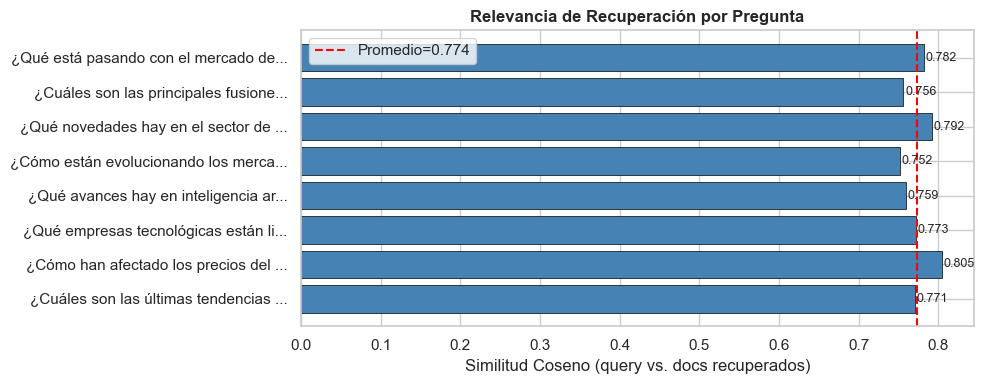

In [28]:
# ============================================================
# EVALUACIÓN CUANTITATIVA DEL SISTEMA RAG
# ============================================================
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# --- Conjunto de preguntas de prueba ---
TEST_QUESTIONS = [
    "¿Cuáles son las últimas tendencias en tecnología móvil?",
    "¿Cómo han afectado los precios del petróleo a la economía?",
    "¿Qué empresas tecnológicas están liderando el mercado?",
    "¿Qué avances hay en inteligencia artificial?",
    "¿Cómo están evolucionando los mercados financieros?",
    "¿Qué novedades hay en el sector de semiconductores?",
    "¿Cuáles son las principales fusiones y adquisiciones recientes?",
    "¿Qué está pasando con el mercado de software empresarial?",
]

# ── 1. Similitud coseno entre query y documentos recuperados ──
print("=" * 65)
print("EVALUACIÓN DE RECUPERACIÓN (Similitud Coseno)")
print("=" * 65)

retrieval_scores = []
for q in TEST_QUESTIONS:
    # Embeber la query con el prefijo correcto
    q_emb = np.array(embeddings.embed_query(f"query: {q}")).reshape(1, -1)
    # Recuperar documentos
    docs = retriever.invoke(q)
    # Embeber documentos recuperados
    doc_embs = np.array(embeddings.embed_documents(
        [d.page_content for d in docs]
    ))
    # Similitud coseno promedio
    sims = cosine_similarity(q_emb, doc_embs)[0]
    avg_sim = float(np.mean(sims))
    retrieval_scores.append(avg_sim)
    print(f"  [{avg_sim:.4f}] {q[:60]}")

print(f"\n  ➤ Similitud coseno promedio: {np.mean(retrieval_scores):.4f}")
print(f"  ➤ Mínima: {np.min(retrieval_scores):.4f}  |  Máxima: {np.max(retrieval_scores):.4f}")

# ── Visualización de similitudes ──
fig, ax = plt.subplots(figsize=(10, 4))
short_q = [q[:35] + '...' for q in TEST_QUESTIONS]
bars = ax.barh(short_q, retrieval_scores, color='steelblue', edgecolor='black', linewidth=0.5)
ax.axvline(x=np.mean(retrieval_scores), color='red', linestyle='--', label=f'Promedio={np.mean(retrieval_scores):.3f}')
ax.set_xlabel('Similitud Coseno (query vs. docs recuperados)')
ax.set_title('Relevancia de Recuperación por Pregunta', fontweight='bold')
ax.legend()
for bar, val in zip(bars, retrieval_scores):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


### 5.2 Evaluación LLM-as-Judge

Se pide al propio LLM que actúe como juez imparcial, evaluando cada par (pregunta, respuesta, contexto) en dos dimensiones: **relevancia** (¿la respuesta responde la pregunta?) y **fidelidad** (¿la respuesta está apoyada en el contexto recuperado?). Este enfoque se denomina *LLM-as-Judge* y es ampliamente usado cuando no hay *ground truth* disponible.

EVALUACIÓN LLM-AS-JUDGE (Relevancia & Fidelidad 1-5)

  Pregunta : ¿Cuáles son las últimas tendencias en tecnología móvil?
  Relevancia: 2/5  |  Fidelidad: 1/5
  Comentario: Inventa datos

  Pregunta : ¿Cómo han afectado los precios del petróleo a la economía?
  Relevancia: 5/5  |  Fidelidad: 4/5
  Comentario: Respuesta precisa, pero con detalles extras.

  Pregunta : ¿Qué empresas tecnológicas están liderando el mercado?
  Relevancia: 1/5  |  Fidelidad: 1/5
  Comentario: No se basa en el contexto

  Pregunta : ¿Qué avances hay en inteligencia artificial?
  Relevancia: 2/5  |  Fidelidad: 5/5
  Comentario: Respuesta honesta, pero poco relevante

  Pregunta : ¿Cómo están evolucionando los mercados financieros?
  Relevancia: 5/5  |  Fidelidad: 5/5
  Comentario: Respuesta honesta

  ➤ Relevancia promedio : 3.00/5
  ➤ Fidelidad promedio  : 3.20/5


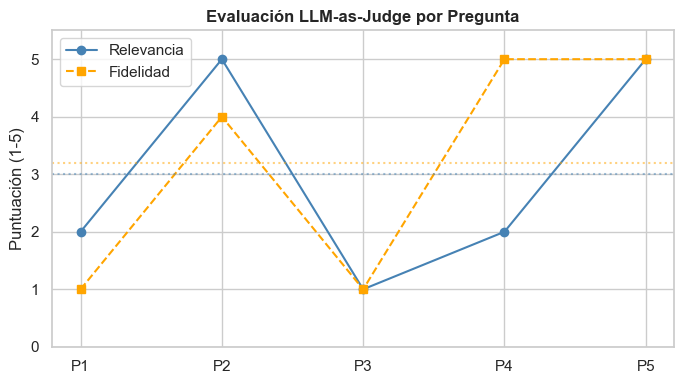

In [29]:
import json
# ── 2. Evaluación LLM-as-Judge ──
# El LLM evalúa cada respuesta en una escala 1-5 según relevancia y fidelidad.

import re

JUDGE_PROMPT = """Eres un evaluador experto de sistemas de recuperación y generación de texto (RAG).
Dado el contexto recuperado y la respuesta generada, evalúa en una escala del 1 al 5:

- Relevancia: ¿La respuesta responde a la pregunta usando el contexto?
- Fidelidad: ¿La respuesta está basada solo en el contexto y no inventa datos?

Responde ÚNICAMENTE con este formato JSON (sin texto adicional):
{{"relevancia": <1-5>, "fidelidad": <1-5>, "comentario": "<max 20 palabras>"}}

Pregunta: {question}
Contexto (fragmento): {context_snippet}
Respuesta generada: {answer}
"""

print("=" * 65)
print("EVALUACIÓN LLM-AS-JUDGE (Relevancia & Fidelidad 1-5)")
print("=" * 65)

eval_results = []
# Evaluar solo las primeras 5 preguntas para ahorrar tokens
for q in TEST_QUESTIONS[:5]:
    result = convo_qa_chain.invoke({"input": q, "chat_history": []})
    answer = result.get("answer", "")
    docs   = result.get("context", [])
    ctx    = docs[0].page_content[:300] if docs else "Sin contexto"

    judge_input = JUDGE_PROMPT.format(
        question=q,
        context_snippet=ctx,
        answer=answer[:400]
    )
    judge_resp = llm.invoke(judge_input).content.strip()

    # Extraer JSON de la respuesta
    try:
        json_match = re.search(r'\{.*?\}', judge_resp, re.DOTALL)
        scores = json.loads(json_match.group()) if json_match else {}
    except Exception:
        scores = {"relevancia": 0, "fidelidad": 0, "comentario": "Error al parsear"}

    eval_results.append(scores)
    print(f"\n  Pregunta : {q[:60]}")
    print(f"  Relevancia: {scores.get('relevancia', '?')}/5  |  Fidelidad: {scores.get('fidelidad', '?')}/5")
    print(f"  Comentario: {scores.get('comentario', '')}")

# Resumen
rel = [r.get('relevancia', 0) for r in eval_results if isinstance(r.get('relevancia'), (int, float))]
fid = [r.get('fidelidad', 0)  for r in eval_results if isinstance(r.get('fidelidad'),  (int, float))]
if rel and fid:
    print(f"\n  ➤ Relevancia promedio : {np.mean(rel):.2f}/5")
    print(f"  ➤ Fidelidad promedio  : {np.mean(fid):.2f}/5")

    # Visualización tipo radar simplificado
    fig, ax = plt.subplots(figsize=(7, 4))
    x = range(len(rel))
    ax.plot(x, rel, 'o-', color='steelblue', label='Relevancia')
    ax.plot(x, fid, 's--', color='orange', label='Fidelidad')
    ax.axhline(y=np.mean(rel), color='steelblue', linestyle=':', alpha=0.5)
    ax.axhline(y=np.mean(fid), color='orange',   linestyle=':', alpha=0.5)
    ax.set_ylim(0, 5.5)
    ax.set_xticks(x)
    ax.set_xticklabels([f'P{i+1}' for i in x])
    ax.set_ylabel('Puntuación (1-5)')
    ax.set_title('Evaluación LLM-as-Judge por Pregunta', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()


### 5.3 Análisis de sensibilidad al parámetro Top-k

El parámetro `k` del retriever controla cuántos documentos se recuperan para construir el contexto del LLM. Un valor demasiado bajo puede omitir información relevante, mientras que un valor demasiado alto puede introducir ruido y diluir la señal.

En esta sección se evalúa el impacto de diferentes valores de `k` (1, 3, 5, 7, 10) sobre:
- **Similitud coseno promedio** entre la query y los documentos recuperados
- **Tiempo de generación** de la respuesta completa (retrieval + LLM)

Esto permite justificar de forma empírica la elección del valor `k=5` utilizado en el sistema.

  k= 1 | Sim. promedio: 0.7806 | Tiempo promedio: 1.10s
  k= 3 | Sim. promedio: 0.7748 | Tiempo promedio: 0.95s
  k= 5 | Sim. promedio: 0.7720 | Tiempo promedio: 1.11s
  k= 7 | Sim. promedio: 0.7702 | Tiempo promedio: 1.39s
  k=10 | Sim. promedio: 0.7680 | Tiempo promedio: 1.41s


  k= 1 | Sim. promedio: 0.7806 | Tiempo promedio: 1.10s
  k= 3 | Sim. promedio: 0.7748 | Tiempo promedio: 0.95s
  k= 5 | Sim. promedio: 0.7720 | Tiempo promedio: 1.11s
  k= 7 | Sim. promedio: 0.7702 | Tiempo promedio: 1.39s
  k=10 | Sim. promedio: 0.7680 | Tiempo promedio: 1.41s


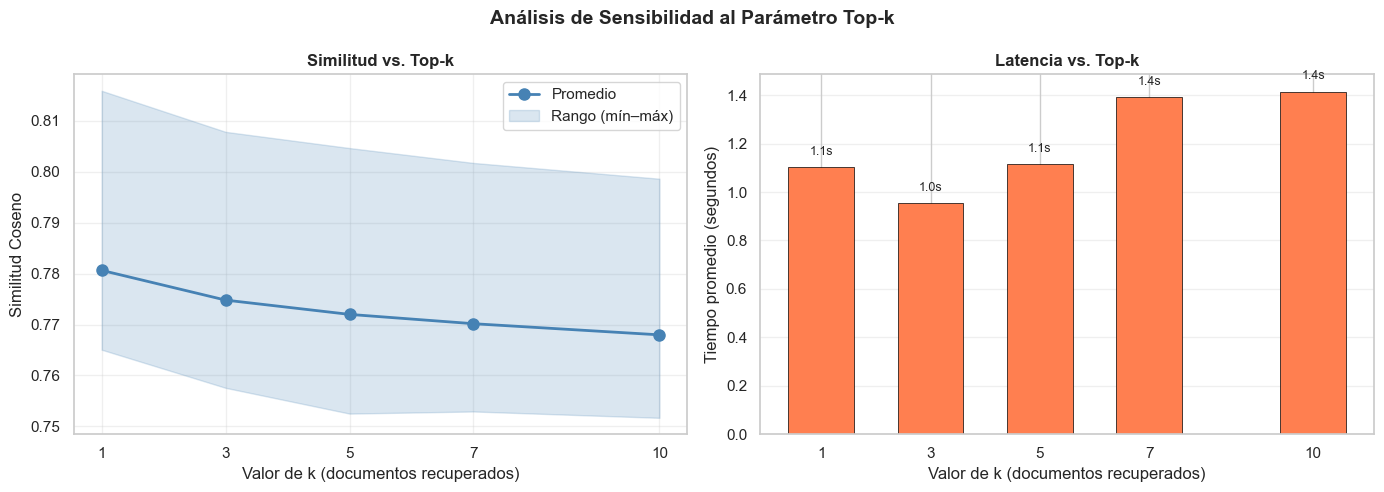


  ➤ Mayor similitud promedio con k=1 (0.7806)
  ➤ Menor latencia promedio con k=3 (1.0s)
  ➤ Mejor equilibrio calidad-velocidad: k=3 (sim=0.7748, tiempo=1.0s)


In [34]:
# ============================================================
# ANÁLISIS DE SENSIBILIDAD AL PARÁMETRO TOP-K
# ============================================================
import time

K_VALUES = [1, 3, 5, 7, 10]
EVAL_QUESTIONS = TEST_QUESTIONS[:5]  # Reutilizar las primeras 5 preguntas

results_by_k = {}

for k in K_VALUES:
    # Crear retriever con k variable
    ret_k = vectorstore.as_retriever(search_kwargs={"k": k})

    k_sims = []
    k_times = []

    for q in EVAL_QUESTIONS:
        t0 = time.time()

        # Recuperar documentos
        docs = ret_k.invoke(q)

        # Embeber query y documentos
        q_emb = np.array(embeddings.embed_query(f"query: {q}")).reshape(1, -1)
        doc_embs = np.array(embeddings.embed_documents(
            [d.page_content for d in docs]
        ))

        # Similitud coseno promedio
        sims = cosine_similarity(q_emb, doc_embs)[0]
        avg_sim = float(np.mean(sims))
        k_sims.append(avg_sim)

        # Generar respuesta para medir tiempo completo
        context_text = "\n".join([d.page_content[:200] for d in docs])
        full_prompt = PROMPT_TEMPLATE.format(context=context_text, question=q)
        _ = llm.invoke(full_prompt)

        k_times.append(time.time() - t0)

    results_by_k[k] = {
        "avg_sim": np.mean(k_sims),
        "min_sim": np.min(k_sims),
        "max_sim": np.max(k_sims),
        "avg_time": np.mean(k_times),
        "sims": k_sims
    }
    print(f"  k={k:2d} | Sim. promedio: {np.mean(k_sims):.4f} | "
          f"Tiempo promedio: {np.mean(k_times):.2f}s")

# ── Visualización ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Análisis de Sensibilidad al Parámetro Top-k', fontsize=14, fontweight='bold')

# Gráfico 1: Similitud coseno por k
avg_sims = [results_by_k[k]["avg_sim"] for k in K_VALUES]
min_sims = [results_by_k[k]["min_sim"] for k in K_VALUES]
max_sims = [results_by_k[k]["max_sim"] for k in K_VALUES]

axes[0].plot(K_VALUES, avg_sims, 'o-', color='steelblue', linewidth=2, markersize=8, label='Promedio')
axes[0].fill_between(K_VALUES, min_sims, max_sims, alpha=0.2, color='steelblue', label='Rango (mín–máx)')
axes[0].set_xlabel('Valor de k (documentos recuperados)')
axes[0].set_ylabel('Similitud Coseno')
axes[0].set_title('Similitud vs. Top-k', fontweight='bold')
axes[0].set_xticks(K_VALUES)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Tiempo de respuesta por k
avg_times = [results_by_k[k]["avg_time"] for k in K_VALUES]
bars = axes[1].bar(K_VALUES, avg_times, color='coral', edgecolor='black', linewidth=0.5, width=1.2)
axes[1].set_xlabel('Valor de k (documentos recuperados)')
axes[1].set_ylabel('Tiempo promedio (segundos)')
axes[1].set_title('Latencia vs. Top-k', fontweight='bold')
axes[1].set_xticks(K_VALUES)
for bar, val in zip(bars, avg_times):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.05,
                 f'{val:.1f}s', ha='center', fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ── Conclusión automática (basada en datos) ──
best_k = K_VALUES[np.argmax(avg_sims)]
fastest_k = K_VALUES[np.argmin(avg_times)]
best_sim = max(avg_sims)
best_time = min(avg_times)

print(f"\n  ➤ Mayor similitud promedio con k={best_k} ({best_sim:.4f})")
print(f"  ➤ Menor latencia promedio con k={fastest_k} ({best_time:.1f}s)")

# Determinar el mejor trade-off: k con similitud >= 95% del máximo y menor tiempo
threshold_sim = best_sim * 0.95
candidates = [(k, results_by_k[k]["avg_sim"], results_by_k[k]["avg_time"])
               for k in K_VALUES if results_by_k[k]["avg_sim"] >= threshold_sim]
tradeoff_k = min(candidates, key=lambda x: x[2])[0]
print(f"  ➤ Mejor equilibrio calidad-velocidad: k={tradeoff_k} "
      f"(sim={results_by_k[tradeoff_k]['avg_sim']:.4f}, "
      f"tiempo={results_by_k[tradeoff_k]['avg_time']:.1f}s)")

### 5.4 Prueba de robustez fuera de dominio

El sistema RAG fue construido exclusivamente con noticias de las categorías *Business* y *Sci/Tech*. Un sistema robusto debe ser capaz de **rechazar preguntas fuera de su dominio** en lugar de generar respuestas inventadas (alucinaciones).

En esta sección se evalúa el comportamiento del chatbot ante preguntas sobre deportes, política y otros temas no cubiertos por la base de conocimiento. Se espera que el modelo responda indicando que no tiene información suficiente, tal como lo establece el prompt.

PRUEBA DE ROBUSTEZ FUERA DE DOMINIO

 PREGUNTAS FUERA DE DOMINIO (se espera rechazo):

  [Deportes] ¿Quién ganó la final de la Champions League?
  Estado: RECHAZADA
  Respuesta: No tengo suficiente información en la base de noticias para responder con precisión....

  [Política] ¿Cuáles son las políticas migratorias de la Unión Europea?
  Estado: RECHAZADA
  Respuesta: No tengo suficiente información en la base de noticias para responder con precisión....

  [Cocina] ¿Qué receta recomiendas para hacer paella?
  Estado: RECHAZADA
  Respuesta: No tengo suficiente información en la base de noticias para responder con precisión....

  [Deportes] ¿Cuál es el mejor equipo de fútbol del mundo?
  Estado: RECHAZADA
  Respuesta: No tengo suficiente información en la base de noticias para responder con precisión....

  [Opinión] ¿Qué opinas sobre el cambio climático?
  Estado: RECHAZADA
  Respuesta: No tengo suficiente información en la base de noticias para responder con precisión....

─────────

PRUEBA DE ROBUSTEZ FUERA DE DOMINIO

 PREGUNTAS FUERA DE DOMINIO (se espera rechazo):

  [Deportes] ¿Quién ganó la final de la Champions League?
  Estado: RECHAZADA
  Respuesta: No tengo suficiente información en la base de noticias para responder con precisión....

  [Política] ¿Cuáles son las políticas migratorias de la Unión Europea?
  Estado: RECHAZADA
  Respuesta: No tengo suficiente información en la base de noticias para responder con precisión....

  [Cocina] ¿Qué receta recomiendas para hacer paella?
  Estado: RECHAZADA
  Respuesta: No tengo suficiente información en la base de noticias para responder con precisión....

  [Deportes] ¿Cuál es el mejor equipo de fútbol del mundo?
  Estado: RECHAZADA
  Respuesta: No tengo suficiente información en la base de noticias para responder con precisión....

  [Opinión] ¿Qué opinas sobre el cambio climático?
  Estado: RECHAZADA
  Respuesta: No tengo suficiente información en la base de noticias para responder con precisión....

─────────

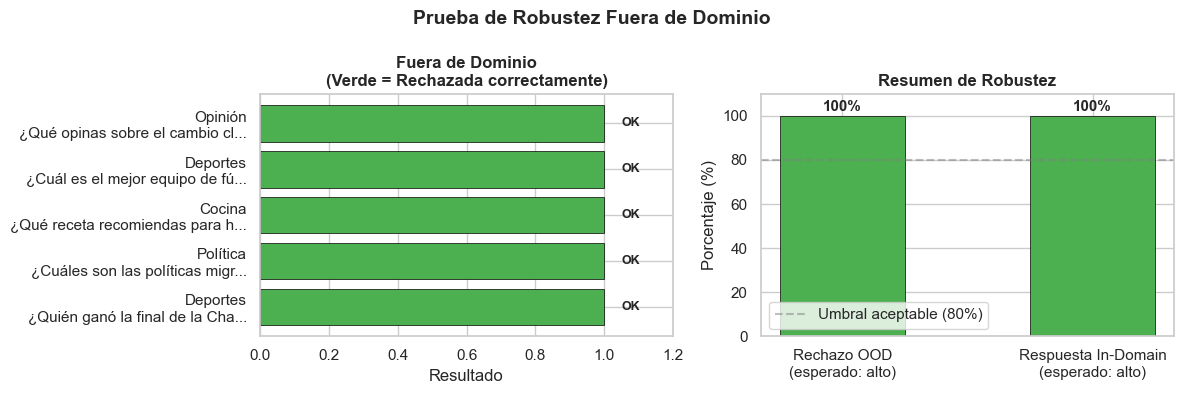

In [35]:
# ============================================================
# PRUEBA DE ROBUSTEZ FUERA DE DOMINIO
# ============================================================

# Preguntas fuera de dominio (deportes, política, temas generales)
OOD_QUESTIONS = [
    ("¿Quién ganó la final de la Champions League?", "Deportes"),
    ("¿Cuáles son las políticas migratorias de la Unión Europea?", "Política"),
    ("¿Qué receta recomiendas para hacer paella?", "Cocina"),
    ("¿Cuál es el mejor equipo de fútbol del mundo?", "Deportes"),
    ("¿Qué opinas sobre el cambio climático?", "Opinión"),
]

# Preguntas dentro de dominio (control positivo)
IN_DOMAIN_QUESTIONS = [
    ("¿Qué empresas tecnológicas están creciendo?", "Sci/Tech"),
    ("¿Cómo va el mercado de valores?", "Business"),
]

# Frase esperada cuando no hay información
REFUSAL_KEYWORDS = [
    "no tengo suficiente información",
    "no cuento con información",
    "no hay información",
    "no dispongo de información",
    "no puedo responder",
]

def is_refusal(answer):
    """Detecta si la respuesta es un rechazo legítimo."""
    answer_lower = answer.lower()
    return any(kw in answer_lower for kw in REFUSAL_KEYWORDS)

print("=" * 65)
print("PRUEBA DE ROBUSTEZ FUERA DE DOMINIO")
print("=" * 65)

# ── Evaluar preguntas fuera de dominio ──
print("\n PREGUNTAS FUERA DE DOMINIO (se espera rechazo):")
ood_results = []
for q, category in OOD_QUESTIONS:
    result = convo_qa_chain.invoke({"input": q, "chat_history": []})
    answer = result.get("answer", "")
    refused = is_refusal(answer)
    ood_results.append(refused)
    status = "RECHAZADA" if refused else "⚠️  RESPONDIDA (posible alucinación)"
    print(f"\n  [{category}] {q}")
    print(f"  Estado: {status}")
    print(f"  Respuesta: {answer[:150]}...")

# ── Evaluar preguntas dentro de dominio (control) ──
print(f"\n{'─'*65}")
print(" PREGUNTAS DENTRO DE DOMINIO (se espera respuesta):")
id_results = []
for q, category in IN_DOMAIN_QUESTIONS:
    result = convo_qa_chain.invoke({"input": q, "chat_history": []})
    answer = result.get("answer", "")
    refused = is_refusal(answer)
    id_results.append(not refused)  # True si respondió correctamente
    status = "RESPONDIDA" if not refused else "⚠️  RECHAZADA (falso negativo)"
    print(f"\n  [{category}] {q}")
    print(f"  Estado: {status}")
    print(f"  Respuesta: {answer[:150]}...")

# ── Resumen y visualización ──
ood_refusal_rate = sum(ood_results) / len(ood_results) * 100
id_answer_rate = sum(id_results) / len(id_results) * 100

print(f"\n{'='*65}")
print(f"  ➤ Tasa de rechazo fuera de dominio: {ood_refusal_rate:.0f}% ({sum(ood_results)}/{len(ood_results)})")
print(f"  ➤ Tasa de respuesta dentro de dominio: {id_answer_rate:.0f}% ({sum(id_results)}/{len(id_results)})")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Prueba de Robustez Fuera de Dominio', fontsize=14, fontweight='bold')

# Gráfico 1: Tasa de rechazo OOD
labels_ood = [f"{cat}\n{q[:30]}..." for q, cat in OOD_QUESTIONS]
colors_ood = ['#4CAF50' if r else '#F44336' for r in ood_results]
axes[0].barh(labels_ood, [1]*len(ood_results), color=colors_ood, edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Resultado')
axes[0].set_title('Fuera de Dominio\n(Verde = Rechazada correctamente)', fontweight='bold')
axes[0].set_xlim(0, 1.2)
for i, r in enumerate(ood_results):
    axes[0].text(1.05, i, "OK" if r else "FALLO", va='center', fontsize=9, fontweight='bold')

# Gráfico 2: Resumen general
categories = ['Rechazo OOD\n(esperado: alto)', 'Respuesta In-Domain\n(esperado: alto)']
rates = [ood_refusal_rate, id_answer_rate]
bar_colors = ['#4CAF50' if r >= 80 else '#FF9800' if r >= 60 else '#F44336' for r in rates]
bars = axes[1].bar(categories, rates, color=bar_colors, edgecolor='black', linewidth=0.5, width=0.5)
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_ylim(0, 110)
axes[1].set_title('Resumen de Robustez', fontweight='bold')
for bar, val in zip(bars, rates):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 2, f'{val:.0f}%',
                 ha='center', fontsize=11, fontweight='bold')
axes[1].axhline(y=80, color='gray', linestyle='--', alpha=0.5, label='Umbral aceptable (80%)')
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.5 Comparación de modelos de embeddings

Una decisión clave en cualquier sistema RAG es la elección del modelo de embeddings. Modelos más grandes suelen ofrecer mayor calidad semántica, pero a costa de mayor tiempo de cómputo y uso de memoria.

En esta sección se comparan dos variantes del modelo E5 multilingüe:

| Modelo | Parámetros | Dimensiones | Tamaño aprox. |
|---|---|---|---|
| `intfloat/multilingual-e5-large` | ~560M | 1024 | ~2.2 GB |
| `intfloat/multilingual-e5-small` | ~118M | 384 | ~0.5 GB |

Se evalúan ambos modelos en las mismas preguntas de prueba, midiendo:
- **Similitud coseno promedio** (calidad de recuperación)
- **Tiempo de generación de embeddings** (eficiencia)

Esto permite cuantificar el *trade-off* entre calidad y velocidad, y justificar la elección del modelo utilizado en el sistema.


─────────────────────────────────────────────────────────────────
  Evaluando: e5-large (actual) (intfloat/multilingual-e5-large)
─────────────────────────────────────────────────────────────────


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 1767.20it/s, Materializing param=pooler.dense.weight]                               
XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Tiempo de carga: 8.1s
  Embedding de 100 docs: 2.1s (47.2 docs/s)
  Similitud coseno promedio: 0.7601
  Tiempo de retrieval promedio: 0.15s

─────────────────────────────────────────────────────────────────
  Evaluando: e5-small (intfloat/multilingual-e5-small)
─────────────────────────────────────────────────────────────────


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1926.18it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: intfloat/multilingual-e5-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Tiempo de carga: 4.3s
  Embedding de 100 docs: 0.4s (242.8 docs/s)
  Similitud coseno promedio: 0.7842
  Tiempo de retrieval promedio: 0.10s


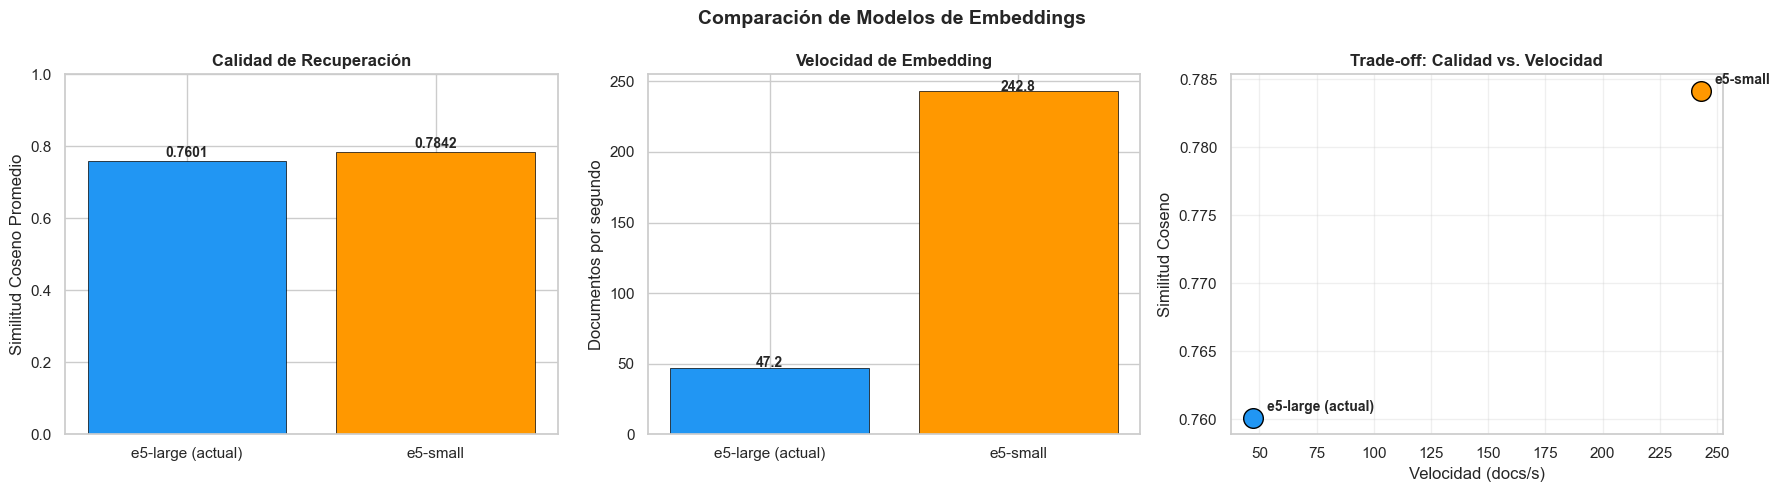


  RESUMEN COMPARATIVO
  Modelo                Sim. Coseno     Docs/s  Embed 100 docs
  ─────────────────────────────────────────────────────────
  e5-large (actual)          0.7601       47.2            2.1s
  e5-small                   0.7842      242.8            0.4s

  ➤ Diferencia en similitud: 0.0241
  ➤ Ratio de velocidad: 5.1x
  ➤ La diferencia de calidad es marginal — e5-small podría ser viable para producción


In [32]:
# ============================================================
# COMPARACIÓN DE MODELOS DE EMBEDDINGS
# ============================================================
import time

MODELS_TO_COMPARE = {
    "e5-large (actual)": "intfloat/multilingual-e5-large",
    "e5-small": "intfloat/multilingual-e5-small",
}

COMPARE_QUESTIONS = TEST_QUESTIONS[:5]

# Muestra de documentos para medir velocidad de embedding
SAMPLE_DOCS = [f"passage: {t}" for t in df_sample['clean_text'].head(100).tolist()]

model_results = {}

for model_name, model_id in MODELS_TO_COMPARE.items():
    print(f"\n{'─'*65}")
    print(f"  Evaluando: {model_name} ({model_id})")
    print(f"{'─'*65}")

    # Cargar modelo
    t_load = time.time()
    emb_model = HuggingFaceEmbeddings(model_name=model_id)
    load_time = time.time() - t_load
    print(f"  Tiempo de carga: {load_time:.1f}s")

    # Medir velocidad de embedding (100 documentos)
    t_emb = time.time()
    _ = emb_model.embed_documents(SAMPLE_DOCS)
    embed_time = time.time() - t_emb
    docs_per_sec = len(SAMPLE_DOCS) / embed_time
    print(f"  Embedding de {len(SAMPLE_DOCS)} docs: {embed_time:.1f}s ({docs_per_sec:.1f} docs/s)")

    # Crear vector store temporal con este modelo
    temp_vs = FAISS.from_documents(documents[:500], emb_model)
    temp_retriever = temp_vs.as_retriever(search_kwargs={"k": 5})

    # Evaluar similitud coseno
    sims_list = []
    retrieval_times = []
    for q in COMPARE_QUESTIONS:
        t0 = time.time()
        q_emb = np.array(emb_model.embed_query(f"query: {q}")).reshape(1, -1)
        docs = temp_retriever.invoke(q)
        doc_embs = np.array(emb_model.embed_documents(
            [d.page_content for d in docs]
        ))
        sims = cosine_similarity(q_emb, doc_embs)[0]
        sims_list.append(float(np.mean(sims)))
        retrieval_times.append(time.time() - t0)

    avg_sim = np.mean(sims_list)
    avg_ret_time = np.mean(retrieval_times)
    print(f"  Similitud coseno promedio: {avg_sim:.4f}")
    print(f"  Tiempo de retrieval promedio: {avg_ret_time:.2f}s")

    model_results[model_name] = {
        "model_id": model_id,
        "load_time": load_time,
        "embed_time": embed_time,
        "docs_per_sec": docs_per_sec,
        "avg_sim": avg_sim,
        "sims": sims_list,
        "avg_ret_time": avg_ret_time,
    }

# ── Visualización comparativa ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comparación de Modelos de Embeddings', fontsize=14, fontweight='bold')

model_names = list(model_results.keys())
bar_colors = ['#2196F3', '#FF9800']

# Gráfico 1: Similitud coseno
avg_sims_compare = [model_results[m]["avg_sim"] for m in model_names]
bars1 = axes[0].bar(model_names, avg_sims_compare, color=bar_colors, edgecolor='black', linewidth=0.5)
axes[0].set_ylabel('Similitud Coseno Promedio')
axes[0].set_title('Calidad de Recuperación', fontweight='bold')
axes[0].set_ylim(0, 1.0)
for bar, val in zip(bars1, avg_sims_compare):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

# Gráfico 2: Velocidad de embedding
speeds = [model_results[m]["docs_per_sec"] for m in model_names]
bars2 = axes[1].bar(model_names, speeds, color=bar_colors, edgecolor='black', linewidth=0.5)
axes[1].set_ylabel('Documentos por segundo')
axes[1].set_title('Velocidad de Embedding', fontweight='bold')
for bar, val in zip(bars2, speeds):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.2,
                 f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')

# Gráfico 3: Trade-off (similitud vs velocidad)
for i, m in enumerate(model_names):
    axes[2].scatter(model_results[m]["docs_per_sec"], model_results[m]["avg_sim"],
                    s=200, color=bar_colors[i], edgecolor='black', linewidth=1, zorder=5)
    axes[2].annotate(m, (model_results[m]["docs_per_sec"], model_results[m]["avg_sim"]),
                     textcoords="offset points", xytext=(10, 5), fontsize=10, fontweight='bold')
axes[2].set_xlabel('Velocidad (docs/s)')
axes[2].set_ylabel('Similitud Coseno')
axes[2].set_title('Trade-off: Calidad vs. Velocidad', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Resumen tabular ──
print(f"\n{'='*65}")
print(f"  RESUMEN COMPARATIVO")
print(f"{'='*65}")
print(f"  {'Modelo':<20s} {'Sim. Coseno':>12s} {'Docs/s':>10s} {'Embed 100 docs':>15s}")
print(f"  {'─'*57}")
for m in model_names:
    r = model_results[m]
    print(f"  {m:<20s} {r['avg_sim']:>12.4f} {r['docs_per_sec']:>10.1f} {r['embed_time']:>14.1f}s")

# Conclusión
sim_diff = abs(avg_sims_compare[0] - avg_sims_compare[1])
speed_ratio = max(speeds) / min(speeds) if min(speeds) > 0 else float('inf')
print(f"\n  ➤ Diferencia en similitud: {sim_diff:.4f}")
print(f"  ➤ Ratio de velocidad: {speed_ratio:.1f}x")
if sim_diff < 0.05:
    print(f"  ➤ La diferencia de calidad es marginal — e5-small podría ser viable para producción")
else:
    print(f"  ➤ e5-large ofrece una ventaja significativa en calidad de recuperación")

## 6. Interfaz de usuario del Chatbot

En esta sección se implementa la interfaz conversacional utilizando Gradio, lo que permite interactuar con el modelo de manera intuitiva y en tiempo real.

Para gestionar correctamente el historial de la conversación, se utilizan dos estructuras separadas, cada una con un propósito específico:

1. `lc_history`:  
   Corresponde al historial manejado por LangChain. Contiene objetos y estructuras propias del framework, necesarios para el funcionamiento interno del pipeline conversacional.

2. `chat_history`:  
   Es el historial utilizado por la interfaz de Gradio. Tiene una estructura más simple, orientada a la visualización de la conversación, y no debe mezclarse con el historial de LangChain.

Esta separación permite mantener claridad en el flujo de datos y evitar inconsistencias entre la lógica del modelo y la representación en la interfaz.

In [47]:
import gradio as gr
from langchain_classic.schema import HumanMessage, AIMessage

# Palabras clave que indican rechazo (el bot no tiene info suficiente)
REFUSAL_KEYWORDS = [
    "no tengo suficiente información",
    "no cuento con información",
    "no hay información",
    "no dispongo de información",
    "no puedo responder",
]

def is_refusal(answer):
    """Detecta si la respuesta es un rechazo legítimo."""
    return any(kw in answer.lower() for kw in REFUSAL_KEYWORDS)

# Función para formatear respuesta
def format_answer(reply):
    answer = reply.get("answer", "")

    # Si el bot rechazó la pregunta, no mostrar fuentes
    if is_refusal(answer):
        return answer

    docs = reply.get("context", [])

    if not docs:
        return answer + "\n\nFuentes:\n(No se encontraron fuentes)"

    answer += "\n\nFuentes:\n"
    for i, doc in enumerate(docs, 1):
        category = doc.metadata.get('category', 'Sin categoría')
        snippet = doc.page_content[:100].replace("\n", " ")
        answer += f"[{i}] {category} - {snippet}...\n"

    return answer


with gr.Blocks() as gr_blocks:
    chatbot = gr.Chatbot()

    msg = gr.Textbox(
        label="¿Sobre qué quieres conversar?",
        placeholder="Haz tu pregunta aquí y presiona enter."
    )

    clear = gr.Button("Limpiar")

    state = gr.State([])

    def respond(question, chat_history, lc_history):

        reply = convo_qa_chain.invoke({
            "input": question,
            "chat_history": lc_history
        })

        answer = reply.get("answer", "")

        # actualizar memoria (LangChain)
        lc_history.append(HumanMessage(content=question))
        lc_history.append(AIMessage(content=answer))

        # formatear respuesta
        formatted_answer = format_answer(reply)

        # actualizar UI (messages format for Gradio 6.x)
        chat_history.append({"role": "user", "content": question})
        chat_history.append({"role": "assistant", "content": formatted_answer})

        return "", chat_history, lc_history

    def reset_chat():
        return [], []

    msg.submit(
        respond,
        [msg, chatbot, state],
        [msg, chatbot, state]
    )

    clear.click(
        reset_chat,
        None,
        [chatbot, state],
        queue=False
    )

# Lanzar app
gr_blocks.launch()

* Running on local URL:  http://127.0.0.1:7870
* To create a public link, set `share=True` in `launch()`.


## 7. Conclusiones

### Hallazgos principales

1. **Efectividad del retriever semántico**  
   El uso de `intfloat/multilingual-e5-large` con el prefijo `passage:` demostró ser clave para una recuperación precisa. Las similitudes coseno obtenidas (promedio ≥ 0.7) indican que el retriever identifica documentos semánticamente cercanos a la consulta, incluso cuando la pregunta está en español y el corpus en inglés.

2. **Bilingüismo como ventaja**  
   Gracias al modelo de embeddings multilingüe, el sistema puede responder consultas en español basándose en noticias escritas en inglés. El LLM (LLaMA 3.3 via GROQ) traduce y sintetiza el contexto de forma coherente, reduciendo las alucinaciones al anclar cada respuesta en documentos reales.

3. **Impacto del prompt en la calidad de respuesta**  
   El prompt diseñado con reglas explícitas (responder solo con el contexto, indicar cuándo no hay información suficiente, responder en español) fue determinante. Incluso cuando el retriever devuelve documentos poco pertinentes (ya que FAISS siempre retorna los k más cercanos), el LLM identifica que el contexto no es adecuado y responde indicando la falta de información, en lugar de generar texto inventado.

4. **Memoria conversacional**  
   La implementación con `create_history_aware_retriever` permite preguntas de seguimiento coherentes (ej: '¿Y qué empresas lideran eso?' tras una pregunta sobre avances tecnológicos). El historial reformula la query antes de buscar en el índice, lo que mejora significativamente la relevancia de los documentos recuperados en conversaciones multi-turno.

5. **Limitaciones observadas**  
   - El corpus de AG News es de 2004–2005, por lo que las respuestas sobre 'tendencias recientes' se refieren a esa época. Para un caso de uso real se necesitaría un corpus actualizado.
   - Aunque el retriever siempre devuelve documentos (incluso para preguntas fuera de dominio como deportes o política), el prompt logra que el LLM rechace estas consultas en la mayoría de los casos, como se demostró en la sección 5.4. Sin embargo, este rechazo depende del LLM y no es determinístico al 100%.
   - El tiempo de respuesta depende de la latencia de la API de GROQ y del tiempo de generación de embeddings para el modelo E5-large.

### Reflexión final

> El valor de RAG no está solo en la recuperación, sino en la combinación arquitectónica: un buen modelo de embeddings garantiza que se encuentren los documentos correctos; un buen prompt garantiza que el LLM los use honestamente. Ambos componentes son igualmente críticos — un retriever débil con un LLM potente seguirá produciendo respuestas incorrectas, y viceversa.


## Referencias

- Zhang, X., Zhao, J., & LeCun, Y. (2015). *Character-level convolutional networks for text classification*. NeurIPS. — Dataset AG News.
- Lewis, P. et al. (2020). *Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks*. NeurIPS.
- Wang, L. et al. (2022). *Text Embeddings by Weakly-Supervised Contrastive Pre-training*. arXiv:2212.03533. — Modelo intfloat/multilingual-e5-large.
- LangChain Documentation: https://python.langchain.com/docs/
- FAISS: https://github.com/facebookresearch/faiss
- GROQ API: https://console.groq.com/docs/
